In [1]:
!python --version

Python 3.12.12


In [2]:
# Cài đặt Unsloth và các công cụ cần thiết (Pandas, Matplotlib cho EDA)
!pip install --upgrade -qqq uv
try: import numpy; install_numpy = f"numpy=={numpy.__version__}"
except: install_numpy = "numpy"

!uv pip install -qqq \
    "torch>=2.6.0" "triton>=3.0.0" {install_numpy} pandas matplotlib \
    "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
    "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
    torchvision bitsandbytes "transformers" \
    git+https://github.com/triton-lang/triton.git@05b2c186c1b6c9a08375389d5efe9cb4c401c075#subdirectory=python/triton_kernels

from huggingface_hub import notebook_login
notebook_login() # Nhập token Hugging Face của bạn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 79.9 MB/s eta 0:00:00


In [3]:
import torch
from unsloth import FastLanguageModel

max_seq_length = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-2-2b-it-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gemma2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.
Unsloth 2026.3.4 patched 26 layers with 26 QKV layers, 26 O layers and 26 MLP layers.


README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

=== THỐNG KÊ DỮ LIỆU HUẤN LUYỆN (12,000 dòng) ===
Độ dài trung bình câu hỏi: 61 ký tự
Độ dài trung bình câu SQL: 76 ký tự
Câu SQL dài nhất: 412 ký tự


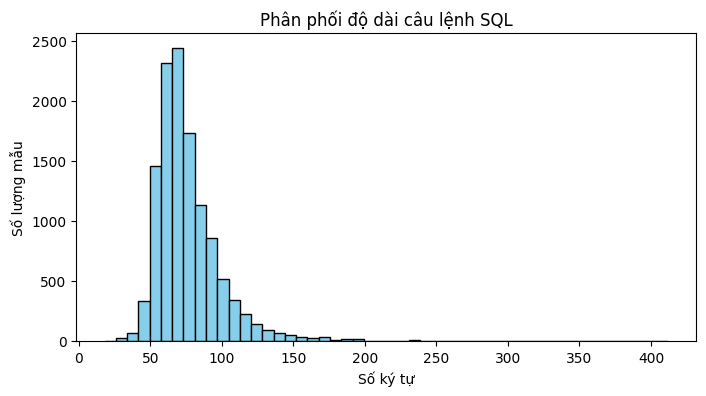

In [4]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tải dataset và xáo trộn, lấy đúng 12,500 dòng (12k train, 500 test)
full_dataset = load_dataset("b-mc2/sql-create-context", split="train")
full_dataset = full_dataset.shuffle(seed=42).select(range(12500))

# Chia tập Train/Test
dataset = full_dataset.train_test_split(test_size=500)
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

# 2. Làm EDA (Exploratory Data Analysis)
df_train = train_dataset.to_pandas()

# Đếm độ dài (số ký tự) của câu hỏi và SQL
df_train['question_len'] = df_train['question'].apply(len)
df_train['sql_len'] = df_train['answer'].apply(len)

print("=== THỐNG KÊ DỮ LIỆU HUẤN LUYỆN (12,000 dòng) ===")
print(f"Độ dài trung bình câu hỏi: {df_train['question_len'].mean():.0f} ký tự")
print(f"Độ dài trung bình câu SQL: {df_train['sql_len'].mean():.0f} ký tự")
print(f"Câu SQL dài nhất: {df_train['sql_len'].max()} ký tự")

# Vẽ biểu đồ phân phối độ dài SQL
plt.figure(figsize=(8, 4))
plt.hist(df_train['sql_len'], bins=50, color='skyblue', edgecolor='black')
plt.title('Phân phối độ dài câu lệnh SQL')
plt.xlabel('Số ký tự')
plt.ylabel('Số lượng mẫu')
plt.show()

In [5]:
# Cấu hình model để chạy inference (dự đoán)
FastLanguageModel.for_inference(model)

test_sample = eval_dataset[0] # Lấy mẫu đầu tiên tập test
schema = test_sample["context"]
question = test_sample["question"]
gold_sql = test_sample["answer"]

# Định dạng Prompt Test (KHÔNG CÓ ĐÁP ÁN)
system_prompt = """You are a problem solving model working on task_description XML block:
<task_description>You are given a database schema and a natural language question.
Generate the SQL query that answers the question.
Input: Schema and Question. Output: A single SQL query. No explanations.</task_description>
Solve only the task in question block. Generate only the answer."""

combined_question = f"Schema:\n{schema}\n\nQuestion: {question}"
messages = [
    {"role": "user", "content": f"{system_prompt}\n\nNow for the real task, solve the task in question block.\nGenerate only the solution, do not generate anything else\n<question>{combined_question}</question>\n"}
]

inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")

# Sinh text
outputs = model.generate(input_ids=inputs, max_new_tokens=128, use_cache=True)
base_response = tokenizer.batch_decode(outputs)[0]
base_sql = base_response.split("<start_of_turn>model\n")[-1].replace("<eos>", "").strip()

print("=== TRƯỚC KHI FINE-TUNE ===")
print("Câu hỏi:", question)
print("\n[ĐÁP ÁN CHUẨN]:", gold_sql)
print("\n[MODEL GỐC TRẢ LỜI]:\n", base_sql)
print("=> Nhận xét: Model gốc thường hay chèn thêm lời giải thích (Sure, here is...) hoặc viết sai chuẩn.")

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

=== TRƯỚC KHI FINE-TUNE ===
Câu hỏi: Name the number of naming for anomic aphasia

[ĐÁP ÁN CHUẨN]: SELECT COUNT(naming) FROM table_2088_1 WHERE type_of_aphasia = "Anomic aphasia"

[MODEL GỐC TRẢ LỜI]:
 ```sql
SELECT COUNT(DISTINCT naming) FROM table_2088_1 WHERE type_of_aphasia = 'anomic aphasia'
```<end_of_turn>
=> Nhận xét: Model gốc thường hay chèn thêm lời giải thích (Sure, here is...) hoặc viết sai chuẩn.


In [6]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

def formatting_prompts_func(examples):
    questions, contexts, answers = examples["question"], examples["context"], examples["answer"]
    texts = []
    for q, c, a in zip(questions, contexts, answers):
        combined_question = f"Schema:\n{c}\n\nQuestion: {q}"
        messages = [
            {"role": "user", "content": f"{system_prompt}\n\nNow for the real task, solve the task in question block.\nGenerate only the solution, do not generate anything else\n<question>{combined_question}</question>\n"},
            {"role": "assistant", "content": a}
        ]
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False))
    return { "text" : texts }

train_dataset = train_dataset.map(formatting_prompts_func, batched = True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched = True)

# Bật lại chế độ train
model.train()

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    args = SFTConfig(
        per_device_train_batch_size = 4, # Batch size lớn hơn vì đã giới hạn 12k dòng
        gradient_accumulation_steps = 4,
        num_train_epochs = 1, # 1 Epoch với 12k dòng là đủ để model học format
        eval_strategy = "steps",
        eval_steps = 100,
        save_strategy = "steps",
        save_steps = 100,
        load_best_model_at_end = True,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 20,
        optim = "adamw_8bit",
        output_dir = "outputs",
        report_to = "none",
    ),
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Bắt đầu train 12,000 dòng...")
trainer.train()

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/12000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Bắt đầu train 12,000 dòng...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 12,000 | Num Epochs = 1 | Total steps = 750
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 20,766,720 of 2,635,108,608 (0.79% trained)


Step,Training Loss,Validation Loss
100,0.417122,0.382983
200,0.344767,0.347857
300,0.345897,0.337499
400,0.331935,0.326582
500,0.331853,0.322133
600,0.317491,0.316567
700,0.310234,0.313404


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=750, training_loss=0.4385591452916463, metrics={'train_runtime': 3707.5002, 'train_samples_per_second': 3.237, 'train_steps_per_second': 0.202, 'total_flos': 3.0686730318249984e+16, 'train_loss': 0.4385591452916463, 'epoch': 1.0})

In [9]:
FastLanguageModel.for_inference(model)

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=128,
    use_cache=True
)

tuned_response = tokenizer.batch_decode(outputs)[0]

# Trích xuất chính xác phần SQL model sinh ra
tuned_sql = tuned_response.split("<start_of_turn>model\n")[-1] \
    .replace("<eos>", "") \
    .replace("<end_of_turn>", "") \
    .strip()

print("=== SAU KHI FINE-TUNE ===")
print("Câu hỏi:", question)
print("\n[ĐÁP ÁN CHUẨN]:", gold_sql)
print("\n[MODEL FINE-TUNE TRẢ LỜI]:\n", tuned_sql)

# So sánh Exact Match (EM) cơ bản
is_match = tuned_sql.lower() == gold_sql.lower()
print(f"\n=> Đánh giá Exact Match: {'✅ KHỚP 100%' if is_match else '❌ CÓ KHÁC BIỆT (Cần check logic)'}")

=== SAU KHI FINE-TUNE ===
Câu hỏi: Name the number of naming for anomic aphasia

[ĐÁP ÁN CHUẨN]: SELECT COUNT(naming) FROM table_2088_1 WHERE type_of_aphasia = "Anomic aphasia"

[MODEL FINE-TUNE TRẢ LỜI]:
 SELECT COUNT(naming) FROM table_2088_1 WHERE type_of_aphasia = "Anomic aphasia"

=> Đánh giá Exact Match: ✅ KHỚP 100%


In [10]:
# THAY BẰNG USERNAME HUGGING FACE CỦA BẠN
hf_model_name = "adamwhite625/gemma-2-2b-text2sql-12k-gguf"

print("Đang nén và đẩy model định dạng GGUF (4-bit)...")
model.push_to_hub_gguf(
    hf_model_name,
    tokenizer,
    quantization_method = "q4_k_m",
    token = True
)
print(f"🎉 Hoàn tất! Model của bạn tại: https://huggingface.co/{hf_model_name}")

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Đang nén và đẩy model định dạng GGUF (4-bit)...
Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/5.23G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:30<00:00, 30.85s/it]


...

Unsloth: All GGUF conversions completed successfully!
Generated files: ['/tmp/unsloth_gguf_zdh762x5_gguf/gemma-2-2b-it.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /tmp/unsloth_gguf_zdh762x5_gguf/gemma-2-2b-it.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /tmp/unsloth_gguf_zdh762x5_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /tmp/unsloth_gguf_zdh762x5_gguf/Modelfile
Unsloth: Uploading GGUF to Huggingface Hub...
Uploading gemma-2-2b-it.Q4_K_M.gguf...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...gemma-2-2b-it.Q4_K_M.gguf:   7%|6         |  112MB / 1.71GB            

Uploading config.json...
Uploading Ollama Modelfile...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/adamwhite625/gemma-2-2b-text2sql-12k-gguf
Unsloth: Cleaning up temporary files...
🎉 Hoàn tất! Model của bạn tại: https://huggingface.co/adamwhite625/gemma-2-2b-text2sql-12k-gguf
